# LSTM - Carteira de Utilities Brasileiras (B3)

**Mercado:** B3 - Setor de Transmissao e Geracao de Energia Eletrica  
**Acoes:** CPFE3 · TAEE11 · EGIE3  
**Framework:** PyTorch  
**Periodo base:** 2019 completo + 2023 em diante (2020-2022 excluido)  
**Objetivo desta etapa:** preparar os dados para testes em 2025

## Justificativa da Carteira - Visao do Economista

### Por que utilities de energia eletrica?

| Ticker | Empresa | Segmento | Vol. 12m | Justificativa |
|--------|---------|----------|----------|---------------|
| `CPFE3.SA` | CPFL Energia | Distribuicao | ~20% | Receita regulada pela ANEEL e contratos de longo prazo |
| `TAEE11.SA` | Taesa | Transmissao | ~19% | Concessoes longas e previsibilidade operacional |
| `EGIE3.SA` | Engie Brasil | Geracao | ~20% | Escala relevante no setor e contratos de energia |

### Correlacao setorial: moderada e heterogenea
As empresas compartilham fatores de risco setoriais, mas a intensidade nao e uniforme entre os pares.
A expectativa tecnica para os retornos e de correlacao positiva em parte dos pares, sem assumir um bloco altamente co-movente.

Fatores estruturais comuns:
1. Regulatorio (ANEEL e regras tarifarias)
2. Macroeconomico (juros e custo de capital)
3. Hidrologico e energetico (condicoes de geracao)
4. Fluxo de investidores com perfil defensivo

### Por que excluir 2020-2022?
O periodo pandemico introduziu choques nao recorrentes: queda atipica da demanda (2020),
crise hidrica relevante (2021) e mudancas emergenciais no marco regulatorio.
Incluir esse regime tende a confundir o aprendizado de dinamicas mais estaveis do periodo-base.

## Coleta de Dados, Pre-processamento e Analise

Esta secao cobre o pipeline completo de preparacao dos dados: coleta via Yahoo Finance, validacao de estacionariedade, engenharia de features tecnicas, selecao por colinearidade e poder preditivo, alem da analise de correlacao entre os ativos da carteira.
O objetivo e entregar um dataset limpo, estacionario e informativo como entrada para o modelo LSTM.

## Instalacao de Dependencias

Instalacao dos pacotes necessarios para coleta de dados, analise estatistica, engenharia de features e visualizacao:
- **yfinance** - coleta de series historicas da B3 via Yahoo Finance
- **pandas-ta** - indicadores tecnicos (RSI, MACD, ATR, Bandas de Bollinger etc.)
- **scikit-learn** - pre-processamento, normalizacao e selecao de features
- **statsmodels** - teste de estacionariedade ADF
- **scipy** - estatisticas auxiliares
- **matplotlib / seaborn** - visualizacoes exploratorias

In [8]:
%pip install yfinance matplotlib scikit-learn scipy statsmodels pandas-ta seaborn --quiet
print('Dependencias principais instaladas.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 79.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 62.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 79.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 15.6 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.1 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26

## Imports e Configuracao

Carregamento das bibliotecas utilizadas ao longo do notebook e configuracao do ambiente de execucao.
A semente aleatoria e fixada para garantir reprodutibilidade nos passos que envolvem amostragem ou inicializacao estocastica.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings, random, time, sys, subprocess
from copy import deepcopy
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)

def check_torch_import(timeout_seconds: int = 90):
    """
    Testa import do torch em subprocesso para evitar travamento silencioso da sessao atual.
    """
    cmd = [sys.executable, "-c", "import torch; print(torch.__version__)" ]
    try:
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout_seconds)
    except subprocess.TimeoutExpired:
        raise RuntimeError(
            "Import de torch excedeu o tempo limite. "
            "No notebook, execute: %pip install --upgrade --force-reinstall --no-cache-dir torch"
        )

    if proc.returncode != 0:
        stderr_msg = (proc.stderr or "").strip()
        raise RuntimeError(
            "Falha ao importar torch no ambiente atual. "
            "No notebook, execute: %pip install --upgrade --force-reinstall --no-cache-dir torch\n"
            f"Detalhe: {stderr_msg}"
        )

    return (proc.stdout or "").strip()

seed_everything(42)
torch_version = check_torch_import(timeout_seconds=90)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

seed_everything(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE} | PyTorch: {torch.__version__}")
print(f"Check subprocess torch: {torch_version}")

Dispositivo: cpu | PyTorch: 2.10.0+cpu
Check subprocess torch: 2.10.0+cpu


## Coleta de Dados - Yahoo Finance

Baixamos dois blocos de dados, preservando a ordem cronologica:
- **2019 completo** (regime pre-pandemia)
- **2023 em diante** (regime pos-pandemia)

 > **Nota sobre o grafico de precos:** a linha reta entre o fim de 2019 e o inicio de 2023 e apenas uma interpolacao
 > visual do matplotlib sobre o gap sem dados de 2020-2022. O pipeline descarta janelas que cruzam esse gap.

Baixando dados do Yahoo Finance...
------------------------------------------------------------------------------------------
CPFE3.SA     | CPFL Energia         | 2019-01-02 -> 2025-12-30 | 997 pregoes | anos: [2019, 2023, 2024, 2025]
  Pregoes por ano: {2019: 248, 2023: 248, 2024: 251, 2025: 250}
TAEE11.SA    | Taesa                | 2019-01-02 -> 2025-12-30 | 997 pregoes | anos: [2019, 2023, 2024, 2025]
  Pregoes por ano: {2019: 248, 2023: 248, 2024: 251, 2025: 250}
EGIE3.SA     | Engie Brasil         | 2019-01-02 -> 2025-12-30 | 997 pregoes | anos: [2019, 2023, 2024, 2025]
  Pregoes por ano: {2019: 248, 2023: 248, 2024: 251, 2025: 250}


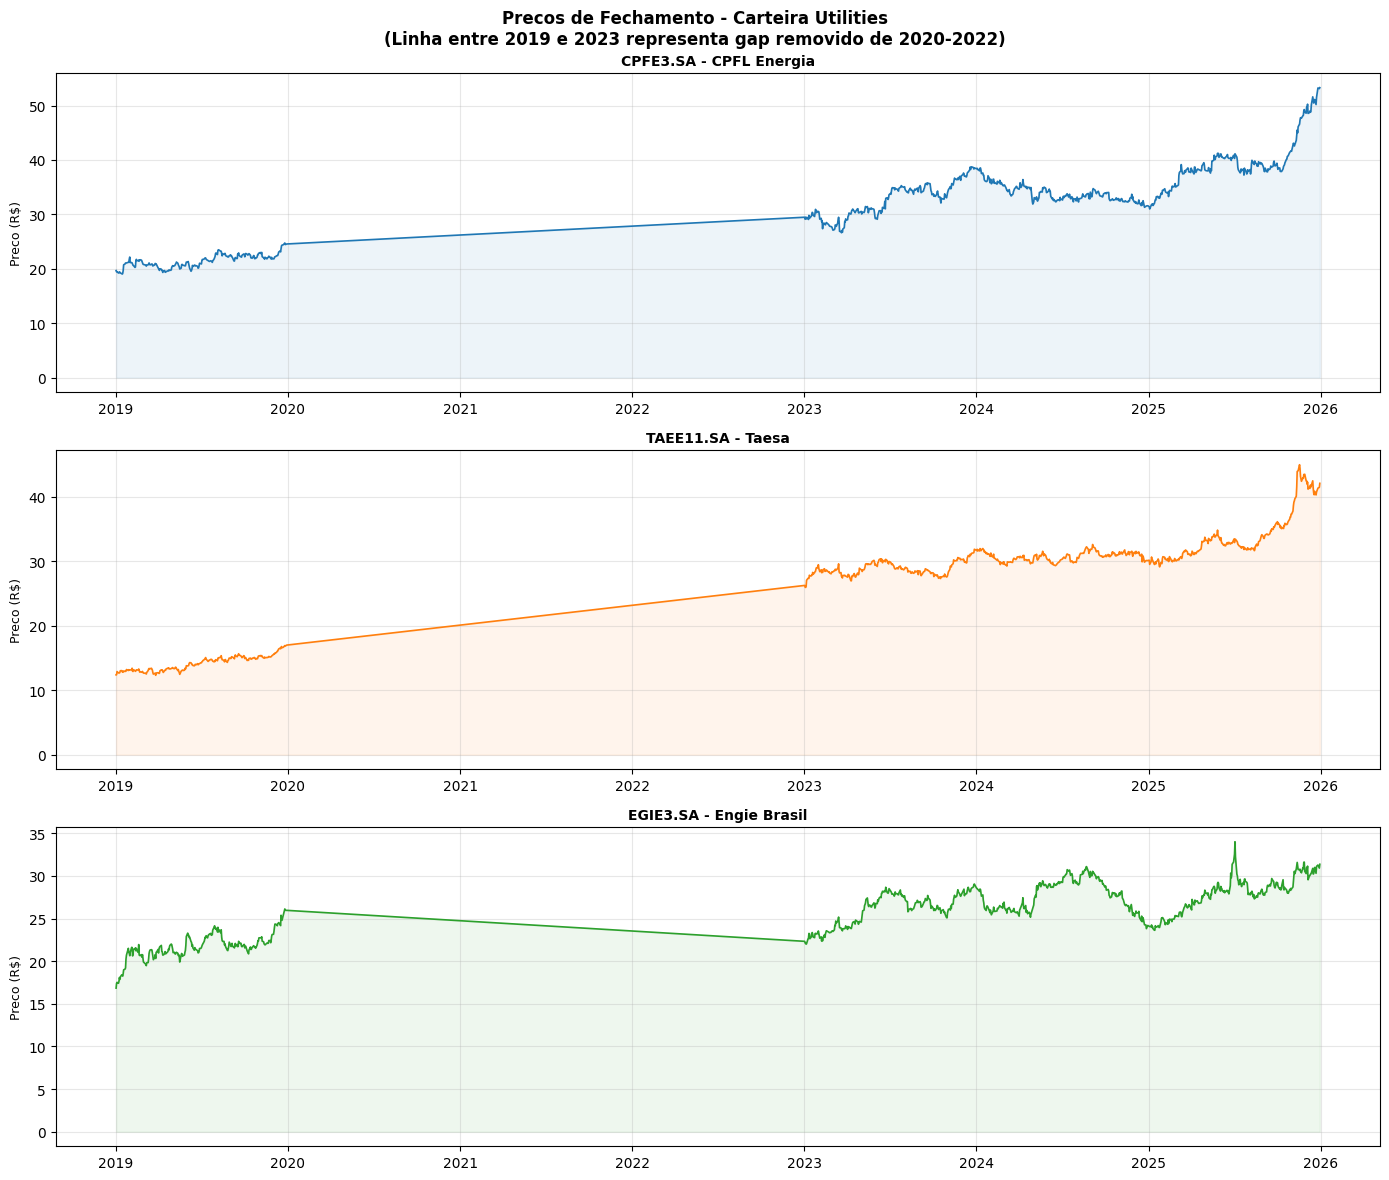


Coleta concluida.


In [6]:
TICKERS = ['CPFE3.SA', 'TAEE11.SA', 'EGIE3.SA']
NOMES = {
    'CPFE3.SA': 'CPFL Energia',
    'TAEE11.SA': 'Taesa',
    'EGIE3.SA': 'Engie Brasil'
}
CORES = {'CPFE3.SA': '#1f77b4', 'TAEE11.SA': '#ff7f0e', 'EGIE3.SA': '#2ca02c'}

PERIODOS = [
    ('2019-01-01', '2019-12-31'),
    # Em yfinance, o parametro end e exclusivo; 2026-01-01 garante captura completa de 2025.
    ('2023-01-01', '2026-01-01'),
]

def resumo_pregoes_por_ano(df: pd.DataFrame) -> pd.Series:
    return df.groupby(df.index.year).size().sort_index()

print('Baixando dados do Yahoo Finance...')
print('-' * 90)

raw_dfs = {}
for ticker in TICKERS:
    frames = []
    for start, end in PERIODOS:
        df_dl = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
        if not df_dl.empty:
            frames.append(df_dl)

    if not frames:
        print(f'{ticker}: sem dados no recorte solicitado.')
        continue

    df_t = pd.concat(frames).sort_index()
    df_t = df_t[(df_t.index.year == 2019) | (df_t.index.year >= 2023)]
    raw_dfs[ticker] = df_t

TICKERS = list(raw_dfs.keys())
if len(TICKERS) == 0:
    raise ValueError('Nenhum ticker retornou dados para o periodo definido.')

for ticker in TICKERS:
    df = raw_dfs[ticker]
    anos = sorted(df.index.year.unique().tolist())
    pregoes_ano = resumo_pregoes_por_ano(df)
    print(
        f'{ticker:12s} | {NOMES[ticker]:20s} | '
        f'{df.index[0].date()} -> {df.index[-1].date()} | {len(df)} pregoes | anos: {anos}'
    )
    print(f'  Pregoes por ano: {pregoes_ano.to_dict()}')

fig, axes = plt.subplots(len(TICKERS), 1, figsize=(14, 4 * len(TICKERS)))
if len(TICKERS) == 1:
    axes = [axes]

fig.suptitle(
    'Precos de Fechamento - Carteira Utilities\n'
    '(Linha entre 2019 e 2023 representa gap removido de 2020-2022)',
    fontsize=12,
    fontweight='bold'
 )

for ax, ticker in zip(axes, TICKERS):
    close = raw_dfs[ticker]['Close'].squeeze()
    ax.plot(raw_dfs[ticker].index, close, color=CORES[ticker], lw=1.2)
    ax.fill_between(raw_dfs[ticker].index, close, alpha=0.08, color=CORES[ticker])
    ax.set_title(f'{ticker} - {NOMES[ticker]}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Preco (R$)', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('\nColeta concluida.')

## Estacionariedade Antes da Engenharia de Features

### Por que nao usar preco bruto na LSTM?

Series de preco em nivel (ex.: `Close`) costumam ser **nao estacionarias**: media e variancia mudam ao longo do tempo.
Para modelos sequenciais, isso costuma gerar tres problemas praticos:

1. O modelo aprende tendencia e regime, em vez da dinamica de curto prazo.
2. A otimizacao fica mais instavel (erro e gradiente variam por escala e regime).
3. A generalizacao piora fora da janela de treino, especialmente com quebras de regime.

Por isso, a abordagem recomendada e transformar o preco em uma serie mais proxima da estacionariedade
(ex.: retornos simples ou log-retornos) e validar formalmente com o teste ADF.

### O que e `LogRet_1d`?

`LogRet_1d` e o **retorno logaritmico diario**:

`LogRet_1d_t = ln(P_t / P_(t-1)) = ln(P_t) - ln(P_(t-1))`

Interpretacao economica e estatistica:
- Mede variacao relativa de preco em termos percentuais aproximados (para variacoes pequenas, e proximo do retorno simples).
- E aditivo no tempo (somar log-retornos diarios gera log-retorno acumulado).
- Costuma ser mais estavel do que o preco em nivel, ajudando a aproximar estacionariedade.

### Regra de decisao (ADF)

- `p > 0.05` -> serie **nao estacionaria**
- `p < 0.05` -> serie **estacionaria**

Nesta etapa, vamos testar para cada ativo:

- `Close` (preco em nivel)
- `LogRet_1d` (diferenca do log-preco)

Se `Close` falhar e `LogRet_1d` passar, seguimos com base estacionaria para a proxima etapa
de calculo de indicadores via `pandas-ta`.

In [7]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series: pd.Series, alpha: float = 0.05) -> dict:
    """Executa ADF e retorna estatisticas principais."""
    s = series.dropna().astype(float)
    if len(s) < 30:
        return {
            "n": len(s),
            "adf_stat": np.nan,
            "p_value": np.nan,
            "lags": np.nan,
            "nobs": np.nan,
            "is_stationary": False,
            "status": "amostra insuficiente"
        }

    stat, pvalue, usedlag, nobs, _, _ = adfuller(s, autolag="AIC")
    is_stat = pvalue < alpha
    return {
        "n": len(s),
        "adf_stat": stat,
        "p_value": pvalue,
        "lags": usedlag,
        "nobs": nobs,
        "is_stationary": is_stat,
        "status": "estacionaria" if is_stat else "nao estacionaria"
    }

print("Teste ADF por ticker (Close vs LogRet_1d)")
print("Regra: p > 0.05 => nao estacionaria | p < 0.05 => estacionaria")
print("-" * 95)

adf_rows = []
for ticker in TICKERS:
    close = raw_dfs[ticker]["Close"].squeeze().dropna()
    logret_1d = np.log(close).diff().dropna()

    res_close = adf_test(close, alpha=0.05)
    res_logret = adf_test(logret_1d, alpha=0.05)

    adf_rows.append({
        "Ticker": ticker,
        "Serie": "Close",
        "N": res_close["n"],
        "ADF Stat": res_close["adf_stat"],
        "p-value": res_close["p_value"],
        "Status": res_close["status"]
    })
    adf_rows.append({
        "Ticker": ticker,
        "Serie": "LogRet_1d",
        "N": res_logret["n"],
        "ADF Stat": res_logret["adf_stat"],
        "p-value": res_logret["p_value"],
        "Status": res_logret["status"]
    })

    print(f"{ticker:12s} | Close p={res_close['p_value']:.6f} -> {res_close['status']}")
    print(f"{ticker:12s} | LogRet p={res_logret['p_value']:.6f} -> {res_logret['status']}")
    print("-" * 95)

adf_results = pd.DataFrame(adf_rows)
adf_results["Conclusao"] = np.where(
    adf_results["p-value"] < 0.05,
    "Estacionaria (rejeita H0 de raiz unitaria)",
    "Nao estacionaria (nao rejeita H0)"
)

print("\nResumo tabular ADF:")
display(adf_results)

# Esta variavel guia a proxima etapa (features com pandas-ta usando base estacionaria).
BASE_SERIE_ESCOLHIDA = "LogRet_1d"
print(f"\nBase recomendada para modelagem sequencial: {BASE_SERIE_ESCOLHIDA}")

Teste ADF por ticker (Close vs LogRet_1d)
Regra: p > 0.05 => nao estacionaria | p < 0.05 => estacionaria
-----------------------------------------------------------------------------------------------
CPFE3.SA     | Close p=0.985965 -> nao estacionaria
CPFE3.SA     | LogRet p=0.000000 -> estacionaria
-----------------------------------------------------------------------------------------------
TAEE11.SA    | Close p=0.826866 -> nao estacionaria
TAEE11.SA    | LogRet p=0.000000 -> estacionaria
-----------------------------------------------------------------------------------------------
EGIE3.SA     | Close p=0.100278 -> nao estacionaria
EGIE3.SA     | LogRet p=0.000000 -> estacionaria
-----------------------------------------------------------------------------------------------

Resumo tabular ADF:


,Ticker,Serie,N,ADF Stat,p-value,Status,Conclusao
0,CPFE3.SA,Close,997,0.537346,9.859651e-01,nao estacionaria,Nao estacionaria (nao rejeita H0)
1,CPFE3.SA,LogRet_1d,996,-32.157711,0.000000e+00,estacionaria,Estacionaria (rejeita H0 de raiz unitaria)
2,TAEE11.SA,Close,997,-0.773206,8.268661e-01,nao estacionaria,Nao estacionaria (nao rejeita H0)
3,TAEE11.SA,LogRet_1d,996,-14.475973,6.488813e-27,estacionaria,Estacionaria (rejeita H0 de raiz unitaria)
4,EGIE3.SA,Close,997,-2.565780,1.002781e-01,nao estacionaria,Nao estacionaria (nao rejeita H0)
5,EGIE3.SA,LogRet_1d,996,-31.955839,0.000000e+00,estacionaria,Estacionaria (rejeita H0 de raiz unitaria)



Base recomendada para modelagem sequencial: LogRet_1d


## Features com pandas-ta + Matriz de Correlacao

Agora que a base-alvo (`LogRet_1d`) foi validada como estacionaria,
vamos construir features tecnicas com `pandas-ta` para cada ticker,
calcular a matriz de correlacao incluindo a target e aplicar poda por alta correlacao.

### Criterio de poda
- Considerar apenas **features explicativas** (a target `LogRet_1d` nunca e removida).
- Remover features redundantes com `|r| > 0.90` entre pares de features.
- Objetivo: reduzir multicolinearidade e complexidade sem perda relevante de informacao.

In [13]:
import pandas_ta as ta

def build_pandasta_features(df: pd.DataFrame) -> pd.DataFrame:
    """Constroi conjunto de features tecnicas e target estacionaria LogRet_1d."""
    x = df.copy()
    close = x['Close'].squeeze().astype(float)
    high = x['High'].squeeze().astype(float)
    low = x['Low'].squeeze().astype(float)
    open_ = x['Open'].squeeze().astype(float)
    volume = x['Volume'].squeeze().astype(float)

    feat = pd.DataFrame(index=x.index)

    # Variaveis base de mercado.
    feat['Open'] = open_
    feat['High'] = high
    feat['Low'] = low
    feat['Close'] = close
    feat['Volume'] = volume

    # Target estacionaria.
    feat['LogRet_1d'] = np.log(close).diff()

    # Trend / moving averages.
    feat['SMA_10'] = ta.sma(close, length=10)
    feat['SMA_20'] = ta.sma(close, length=20)
    feat['EMA_12'] = ta.ema(close, length=12)
    feat['EMA_26'] = ta.ema(close, length=26)

    # Momentum.
    feat['RSI_14'] = ta.rsi(close, length=14)
    feat['ROC_10'] = ta.roc(close, length=10)
    macd = ta.macd(close, fast=12, slow=26, signal=9)
    if macd is not None:
        feat = feat.join(macd)

    # Volatilidade.
    bb = ta.bbands(close, length=20, std=2.0)
    if bb is not None:
        feat = feat.join(bb)
    feat['ATR_14'] = ta.atr(high, low, close, length=14)

    # Osciladores / tendencia.
    stoch = ta.stoch(high, low, close, k=14, d=3, smooth_k=3)
    if stoch is not None:
        feat = feat.join(stoch)
    adx = ta.adx(high, low, close, length=14)
    if adx is not None:
        feat = feat.join(adx)
    feat['CCI_20'] = ta.cci(high, low, close, length=20)

    # Volume.
    feat['MFI_14'] = ta.mfi(high, low, close, volume, length=14)
    feat['OBV'] = ta.obv(close, volume)

    feat = feat.replace([np.inf, -np.inf], np.nan)

    # Remove colunas completamente vazias e colunas com excesso de faltantes.
    feat = feat.dropna(axis=1, how='all')
    na_ratio = feat.isna().mean()
    cols_keep = na_ratio[na_ratio <= 0.35].index.tolist()
    feat = feat[cols_keep].dropna()

    return feat

features_full = {}
for ticker in TICKERS:
    features_full[ticker] = build_pandasta_features(raw_dfs[ticker])
    print(f"{ticker}: {features_full[ticker].shape[0]} linhas x {features_full[ticker].shape[1]} colunas")

CPFE3.SA: 964 linhas x 31 colunas
TAEE11.SA: 964 linhas x 31 colunas
EGIE3.SA: 964 linhas x 31 colunas


In [14]:
def correlation_pruning(
    df_feat: pd.DataFrame,
    target_col: str = 'LogRet_1d',
    threshold: float = 0.90
):
    """
    Remove features altamente correlacionadas entre si (|r| > threshold).
    A target nunca e removida.
    """
    corr = df_feat.corr(numeric_only=True)

    feature_cols = [c for c in corr.columns if c != target_col]
    corr_features = corr.loc[feature_cols, feature_cols].abs()

    upper = corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if (upper[col] > threshold).any()]

    # Gera pares de alta correlacao sem usar stack (evita incompatibilidade de versao pandas).
    pairs_list = []
    cols = corr_features.columns.tolist()
    arr = corr_features.values
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            val = arr[i, j]
            if np.isfinite(val) and val > threshold:
                pairs_list.append((cols[i], cols[j], float(val)))

    high_pairs = pd.DataFrame(pairs_list, columns=['Feature_A', 'Feature_B', 'abs_r'])
    if not high_pairs.empty:
        high_pairs = high_pairs.sort_values('abs_r', ascending=False).reset_index(drop=True)

    df_pruned = df_feat.drop(columns=to_drop, errors='ignore')
    return corr, high_pairs, to_drop, df_pruned

corr_mats = {}
high_corr_pairs = {}
dropped_features = {}
features_pruned = {}

for ticker in TICKERS:
    corr, pairs, to_drop, df_pruned = correlation_pruning(
        features_full[ticker], target_col='LogRet_1d', threshold=0.90
    )
    corr_mats[ticker] = corr
    high_corr_pairs[ticker] = pairs
    dropped_features[ticker] = to_drop
    features_pruned[ticker] = df_pruned

    print("\n" + "=" * 105)
    print(f"Ticker: {ticker}")
    print(f"Total de colunas (features + target): {features_full[ticker].shape[1]}")
    print(f"Features removidas por |r| > 0.90: {len(to_drop)}")
    print(f"Total final (incluindo target): {df_pruned.shape[1]}")

    if len(to_drop) > 0:
        print("Features removidas:")
        print(to_drop)
    else:
        print("Nenhuma feature removida pelo criterio de correlacao.")

    print("\nTop pares com |r| > 0.90 (features x features):")
    if pairs.empty:
        print("Nenhum par acima do limiar.")
    else:
        display(pairs.head(15))

    print("Matriz de correlacao (amostra - primeiras 12 linhas/colunas):")
    display(corr.iloc[:12, :12].round(3))

print("\nConsolidado de colunas finais por ticker (com target):")
for ticker in TICKERS:
    print(f"{ticker}: {features_pruned[ticker].shape[1]} colunas")


Ticker: CPFE3.SA
Total de colunas (features + target): 31
Features removidas por |r| > 0.90: 13
Total final (incluindo target): 18
Features removidas:
['High', 'Low', 'Close', 'SMA_10', 'SMA_20', 'EMA_12', 'EMA_26', 'MACDs_12_26_9', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'STOCHd_14_3_3', 'ADXR_14_2']

Top pares com |r| > 0.90 (features x features):


,Feature_A,Feature_B,abs_r
0,SMA_20,BBM_20_2.0_2.0,1.000000
1,SMA_10,EMA_12,0.999685
2,High,Close,0.999301
3,Open,Low,0.999256
4,Low,Close,0.999206
5,EMA_26,BBM_20_2.0_2.0,0.999107
6,SMA_20,EMA_26,0.999107
7,High,Low,0.999093
8,Open,High,0.998997
9,Open,Close,0.998243


Matriz de correlacao (amostra - primeiras 12 linhas/colunas):


,Open,High,Low,Close,Volume,LogRet_1d,SMA_10,SMA_20,EMA_12,EMA_26,RSI_14,ROC_10
Open,1.000,0.999,0.999,0.998,-0.069,0.012,0.996,0.988,0.996,0.989,0.253,0.140
High,0.999,1.000,0.999,0.999,-0.057,0.039,0.995,0.988,0.995,0.988,0.263,0.148
Low,0.999,0.999,1.000,0.999,-0.074,0.035,0.995,0.988,0.996,0.989,0.260,0.145
Close,0.998,0.999,0.999,1.000,-0.064,0.059,0.995,0.987,0.995,0.987,0.271,0.153
Volume,-0.069,-0.057,-0.074,-0.064,1.000,0.044,-0.071,-0.077,-0.072,-0.078,0.086,0.066
LogRet_1d,0.012,0.039,0.035,0.059,0.044,1.000,0.003,-0.003,0.006,0.000,0.352,0.319
SMA_10,0.996,0.995,0.995,0.995,-0.071,0.003,1.000,0.997,1.000,0.996,0.189,0.067
SMA_20,0.988,0.988,0.988,0.987,-0.077,-0.003,0.997,1.000,0.998,0.999,0.126,0.010
EMA_12,0.996,0.995,0.996,0.995,-0.072,0.006,1.000,0.998,1.000,0.997,0.184,0.067
EMA_26,0.989,0.988,0.989,0.987,-0.078,0.000,0.996,0.999,0.997,1.000,0.123,0.021



Ticker: TAEE11.SA
Total de colunas (features + target): 31
Features removidas por |r| > 0.90: 13
Total final (incluindo target): 18
Features removidas:
['High', 'Low', 'Close', 'SMA_10', 'SMA_20', 'EMA_12', 'EMA_26', 'MACDs_12_26_9', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'STOCHd_14_3_3', 'ADXR_14_2']

Top pares com |r| > 0.90 (features x features):


...


Ticker: EGIE3.SA
Total de colunas (features + target): 31
Features removidas por |r| > 0.90: 14
Total final (incluindo target): 17
Features removidas:
['High', 'Low', 'Close', 'SMA_10', 'SMA_20', 'EMA_12', 'EMA_26', 'MACDs_12_26_9', 'BBL_20_2.0_2.0', 'BBM_20_2.0_2.0', 'BBU_20_2.0_2.0', 'STOCHd_14_3_3', 'ADXR_14_2', 'OBV']

Top pares com |r| > 0.90 (features x features):


,Feature_A,Feature_B,abs_r
0,SMA_20,BBM_20_2.0_2.0,1.000000
1,SMA_10,EMA_12,0.998686
2,High,Close,0.997379
3,Open,Low,0.997366
4,Low,Close,0.997184
5,SMA_20,EMA_26,0.996998
6,EMA_26,BBM_20_2.0_2.0,0.996998
7,High,Low,0.996866
8,Open,High,0.996859
9,Open,Close,0.993545


Matriz de correlacao (amostra - primeiras 12 linhas/colunas):


,Open,High,Low,Close,Volume,LogRet_1d,SMA_10,SMA_20,EMA_12,EMA_26,RSI_14,ROC_10
Open,1.000,0.997,0.997,0.994,-0.074,-0.042,0.985,0.967,0.988,0.971,0.146,0.140
High,0.997,1.000,0.997,0.997,-0.059,0.011,0.982,0.962,0.985,0.966,0.172,0.164
Low,0.997,0.997,1.000,0.997,-0.084,0.009,0.983,0.965,0.987,0.970,0.163,0.154
Close,0.994,0.997,0.997,1.000,-0.073,0.059,0.979,0.961,0.983,0.965,0.186,0.175
Volume,-0.074,-0.059,-0.084,-0.073,1.000,-0.013,-0.080,-0.091,-0.082,-0.089,0.034,0.046
LogRet_1d,-0.042,0.011,0.009,0.059,-0.013,1.000,-0.047,-0.044,-0.038,-0.041,0.341,0.296
SMA_10,0.985,0.982,0.983,0.979,-0.080,-0.047,1.000,0.989,0.999,0.989,0.033,0.008
SMA_20,0.967,0.962,0.965,0.961,-0.091,-0.044,0.989,1.000,0.993,0.997,-0.067,-0.079
EMA_12,0.988,0.985,0.987,0.983,-0.082,-0.038,0.999,0.993,1.000,0.993,0.030,0.017
EMA_26,0.971,0.966,0.970,0.965,-0.089,-0.041,0.989,0.997,0.993,1.000,-0.067,-0.049



Consolidado de colunas finais por ticker (com target):
CPFE3.SA: 18 colunas
TAEE11.SA: 18 colunas
EGIE3.SA: 17 colunas


In [16]:
# Bloco extra: features finais escolhidas + mini explicacao de cada uma.
feature_explanations = {
    'LogRet_1d': 'Target: retorno logaritmico diario (variacao relativa de curto prazo).',
    'Open': 'Preco de abertura do pregao.',
    'High': 'Preco maximo intradiario.',
    'Low': 'Preco minimo intradiario.',
    'Close': 'Preco de fechamento do pregao.',
    'Volume': 'Quantidade negociada no dia.',
    'SMA_10': 'Media movel simples de 10 periodos.',
    'SMA_20': 'Media movel simples de 20 periodos.',
    'EMA_12': 'Media movel exponencial de 12 periodos.',
    'EMA_26': 'Media movel exponencial de 26 periodos.',
    'RSI_14': 'Indice de forca relativa (0-100), momentum de 14 periodos.',
    'ROC_10': 'Rate of Change: variacao percentual em 10 periodos.',
    'MACD_12_26_9': 'Linha MACD: EMA(12) - EMA(26).',
    'MACDh_12_26_9': 'Histograma MACD: distancia entre MACD e sinal.',
    'MACDs_12_26_9': 'Linha de sinal do MACD (EMA de 9 periodos da linha MACD).',
    'BBL_20_2.0_2.0': 'Banda inferior de Bollinger (20 periodos, 2 desvios).',
    'BBM_20_2.0_2.0': 'Banda central de Bollinger (media movel).',
    'BBU_20_2.0_2.0': 'Banda superior de Bollinger.',
    'BBB_20_2.0_2.0': 'Largura das bandas de Bollinger (proxy de volatilidade).',
    'BBP_20_2.0_2.0': 'Posicao do preco dentro das bandas de Bollinger.',
    'ATR_14': 'Average True Range: volatilidade media real em 14 periodos.',
    'STOCHk_14_3_3': 'Estocastico %K: posicao do fechamento no range recente.',
    'STOCHd_14_3_3': 'Estocastico %D: media suavizada do %K.',
    'ADX_14': 'Forca da tendencia (nao indica direcao).',
    'DMP_14': 'Componente direcional positivo (+DI) do ADX.',
    'DMN_14': 'Componente direcional negativo (-DI) do ADX.',
    'ADXR_14_2': 'Media do ADX para suavizar leitura de tendencia.',
    'CCI_20': 'Commodity Channel Index: desvio do preco em relacao a media.',
    'MFI_14': 'Money Flow Index: oscilador de fluxo de capital com volume.',
    'OBV': 'On-Balance Volume: acumulacao/distribuicao pelo volume.'
}

selected_feature_docs = {}

for ticker in TICKERS:
    selected_cols = [col for col in features_pruned[ticker].columns if col != 'LogRet_1d']
    final_cols_ordered = ['LogRet_1d'] + selected_cols

    docs_df = pd.DataFrame({
        'Variavel': final_cols_ordered,
        'Papel': ['Target'] + ['Feature'] * len(selected_cols),
        'Mini_Explicacao': [feature_explanations.get(c, 'Descricao nao mapeada.') for c in final_cols_ordered]
    })

    selected_feature_docs[ticker] = docs_df

    print('\n' + '=' * 105)
    print(f'Ticker: {ticker}')
    print(f'Total final de variaveis (target + features): {len(final_cols_ordered)}')
    display(docs_df)


Ticker: CPFE3.SA
Total final de variaveis (target + features): 18


,Variavel,Papel,Mini_Explicacao
0,LogRet_1d,Target,Target: retorno logaritmico diario (variacao r...
1,Open,Feature,Preco de abertura do pregao.
2,Volume,Feature,Quantidade negociada no dia.
3,RSI_14,Feature,"Indice de forca relativa (0-100), momentum de ..."
4,ROC_10,Feature,Rate of Change: variacao percentual em 10 peri...
5,MACD_12_26_9,Feature,Linha MACD: EMA(12) - EMA(26).
6,MACDh_12_26_9,Feature,Histograma MACD: distancia entre MACD e sinal.
7,BBB_20_2.0_2.0,Feature,Largura das bandas de Bollinger (proxy de vola...
8,BBP_20_2.0_2.0,Feature,Posicao do preco dentro das bandas de Bollinger.
9,ATR_14,Feature,Average True Range: volatilidade media real em...



Ticker: TAEE11.SA
Total final de variaveis (target + features): 18


,Variavel,Papel,Mini_Explicacao
0,LogRet_1d,Target,Target: retorno logaritmico diario (variacao r...
1,Open,Feature,Preco de abertura do pregao.
2,Volume,Feature,Quantidade negociada no dia.
3,RSI_14,Feature,"Indice de forca relativa (0-100), momentum de ..."
4,ROC_10,Feature,Rate of Change: variacao percentual em 10 peri...
5,MACD_12_26_9,Feature,Linha MACD: EMA(12) - EMA(26).
6,MACDh_12_26_9,Feature,Histograma MACD: distancia entre MACD e sinal.
7,BBB_20_2.0_2.0,Feature,Largura das bandas de Bollinger (proxy de vola...
8,BBP_20_2.0_2.0,Feature,Posicao do preco dentro das bandas de Bollinger.
9,ATR_14,Feature,Average True Range: volatilidade media real em...



Ticker: EGIE3.SA
Total final de variaveis (target + features): 17


,Variavel,Papel,Mini_Explicacao
0,LogRet_1d,Target,Target: retorno logaritmico diario (variacao r...
1,Open,Feature,Preco de abertura do pregao.
2,Volume,Feature,Quantidade negociada no dia.
3,RSI_14,Feature,"Indice de forca relativa (0-100), momentum de ..."
4,ROC_10,Feature,Rate of Change: variacao percentual em 10 peri...
5,MACD_12_26_9,Feature,Linha MACD: EMA(12) - EMA(26).
6,MACDh_12_26_9,Feature,Histograma MACD: distancia entre MACD e sinal.
7,BBB_20_2.0_2.0,Feature,Largura das bandas de Bollinger (proxy de vola...
8,BBP_20_2.0_2.0,Feature,Posicao do preco dentro das bandas de Bollinger.
9,ATR_14,Feature,Average True Range: volatilidade media real em...


## Poder Preditivo - Mutual Information com o Target

A **Mutual Information (MI)** mede o quanto cada feature reduz a incerteza sobre o alvo.
Diferente da correlacao de Pearson, a MI captura relacoes **nao lineares**,
o que e particularmente util para modelos sequenciais como LSTM.

Nesta etapa, definimos o alvo como **retorno de 1 dia a frente**:

`Target_t+1 = LogRet_1d.shift(-1)`

Interpretacao pratica:
- MI alta: feature tem sinal informacional relevante para prever o proximo retorno.
- MI proxima de zero: feature se comporta como ruido para o modelo.

In [17]:
from sklearn.feature_selection import mutual_info_regression

MI_NOISE_THRESHOLD = 1e-4  # MI muito baixa: feature com pouca informacao preditiva.
mi_results = {}
mi_noise_features = {}
mi_selected_features = {}

for ticker in TICKERS:
    df_mi = features_pruned[ticker].copy()
    df_mi['Target_t+1'] = df_mi['LogRet_1d'].shift(-1)
    df_mi = df_mi.dropna().reset_index(drop=True)

    # X inclui variaveis disponiveis no tempo t para prever retorno em t+1.
    x_cols = [c for c in df_mi.columns if c != 'Target_t+1']
    X = df_mi[x_cols]
    y = df_mi['Target_t+1']

    mi_values = mutual_info_regression(X, y, random_state=42)
    mi_df = pd.DataFrame({
        'Feature': x_cols,
        'MI': mi_values
    }).sort_values('MI', ascending=False).reset_index(drop=True)

    mi_df['Classificacao'] = np.where(
        mi_df['MI'] <= MI_NOISE_THRESHOLD,
        'Ruido (MI ~ 0)',
        'Informativa'
    )

    mi_results[ticker] = mi_df
    mi_noise_features[ticker] = mi_df.loc[mi_df['MI'] <= MI_NOISE_THRESHOLD, 'Feature'].tolist()
    mi_selected_features[ticker] = mi_df.loc[mi_df['MI'] > MI_NOISE_THRESHOLD, 'Feature'].tolist()

    print('\n' + '=' * 105)
    print(f'Ticker: {ticker}')
    print(f'Amostra para MI: {len(df_mi)} observacoes')
    print(f'Features avaliadas: {len(x_cols)}')
    print(f'Features informativas (MI > {MI_NOISE_THRESHOLD}): {len(mi_selected_features[ticker])}')
    print(f'Features com MI ~ 0 (ruido): {len(mi_noise_features[ticker])}')

    print('\nTop 12 features por MI:')
    display(mi_df.head(12))

    if mi_noise_features[ticker]:
        print('Features classificadas como ruido (MI ~ 0):')
        print(mi_noise_features[ticker])
    else:
        print('Nenhuma feature foi classificada como ruido no limiar atual.')


Ticker: CPFE3.SA
Amostra para MI: 963 observacoes
Features avaliadas: 18
Features informativas (MI > 0.0001): 13
Features com MI ~ 0 (ruido): 5

Top 12 features por MI:


,Feature,MI,Classificacao
0,Volume,0.085608,Informativa
1,BBB_20_2.0_2.0,0.073013,Informativa
2,ATR_14,0.044850,Informativa
3,CCI_20,0.040023,Informativa
4,ROC_10,0.022637,Informativa
5,MACD_12_26_9,0.022051,Informativa
6,DMP_14,0.019662,Informativa
7,RSI_14,0.018543,Informativa
8,OBV,0.012778,Informativa
9,Open,0.007187,Informativa


Features classificadas como ruido (MI ~ 0):
['LogRet_1d', 'BBP_20_2.0_2.0', 'MACDh_12_26_9', 'STOCHh_14_3_3', 'MFI_14']

Ticker: TAEE11.SA
Amostra para MI: 963 observacoes
Features avaliadas: 18
Features informativas (MI > 0.0001): 8
Features com MI ~ 0 (ruido): 10

Top 12 features por MI:


,Feature,MI,Classificacao
0,Open,0.030781,Informativa
1,RSI_14,0.028649,Informativa
2,BBB_20_2.0_2.0,0.026956,Informativa
3,OBV,0.021089,Informativa
4,Volume,0.013662,Informativa
5,ATR_14,0.013149,Informativa
6,STOCHk_14_3_3,0.007984,Informativa
7,MACD_12_26_9,0.004577,Informativa
8,ROC_10,0.000000,Ruido (MI ~ 0)
9,LogRet_1d,0.000000,Ruido (MI ~ 0)


Features classificadas como ruido (MI ~ 0):
['ROC_10', 'LogRet_1d', 'BBP_20_2.0_2.0', 'MACDh_12_26_9', 'ADX_14', 'STOCHh_14_3_3', 'DMP_14', 'DMN_14', 'CCI_20', 'MFI_14']

Ticker: EGIE3.SA
Amostra para MI: 963 observacoes
Features avaliadas: 17
Features informativas (MI > 0.0001): 6
Features com MI ~ 0 (ruido): 11

Top 12 features por MI:


,Feature,MI,Classificacao
0,DMN_14,0.042607,Informativa
1,STOCHh_14_3_3,0.014255,Informativa
2,CCI_20,0.007778,Informativa
3,MACDh_12_26_9,0.006933,Informativa
4,STOCHk_14_3_3,0.003118,Informativa
5,LogRet_1d,0.001534,Informativa
6,Open,0.000000,Ruido (MI ~ 0)
7,RSI_14,0.000000,Ruido (MI ~ 0)
8,Volume,0.000000,Ruido (MI ~ 0)
9,BBP_20_2.0_2.0,0.000000,Ruido (MI ~ 0)


Features classificadas como ruido (MI ~ 0):
['Open', 'RSI_14', 'Volume', 'BBP_20_2.0_2.0', 'BBB_20_2.0_2.0', 'MACD_12_26_9', 'ROC_10', 'ADX_14', 'ATR_14', 'DMP_14', 'MFI_14']


## Filtro Final - Remocao de Features de Ruido por MI

Apos estimar MI, removemos os preditores com `MI ~ 0`,
mantendo apenas variaveis informativas para prever `Target_t+1`.

Regra aplicada por ticker:
- Feature de ruido: `MI <= MI_NOISE_THRESHOLD`
- Feature mantida: `MI > MI_NOISE_THRESHOLD`

Saida desta etapa: `datasets_mi_filtered[ticker]`,
com preditores filtrados + coluna alvo `Target_t+1`.

In [18]:
datasets_mi_filtered = {}
mi_filter_report = {}

for ticker in TICKERS:
    # Reconstrui base supervisionada com alvo de 1 dia a frente.
    df_base = features_pruned[ticker].copy()
    df_base['Target_t+1'] = df_base['LogRet_1d'].shift(-1)
    df_base = df_base.dropna().reset_index(drop=True)

    predictor_cols = [c for c in df_base.columns if c != 'Target_t+1']
    noise_set = set(mi_noise_features.get(ticker, []))

    kept_predictors = [c for c in predictor_cols if c not in noise_set]
    removed_predictors = [c for c in predictor_cols if c in noise_set]

    df_final = df_base[kept_predictors + ['Target_t+1']].copy()
    datasets_mi_filtered[ticker] = df_final

    mi_filter_report[ticker] = {
        'n_obs': len(df_final),
        'n_predictors_before': len(predictor_cols),
        'n_predictors_removed': len(removed_predictors),
        'n_predictors_kept': len(kept_predictors),
        'removed_predictors': removed_predictors,
        'kept_predictors': kept_predictors
    }

    print('\n' + '=' * 105)
    print(f'Ticker: {ticker}')
    print(f'Observacoes finais: {len(df_final)}')
    print(f'Preditores antes do filtro MI: {len(predictor_cols)}')
    print(f'Preditores removidos (ruido): {len(removed_predictors)}')
    print(f'Preditores mantidos: {len(kept_predictors)}')
    print(f'Total de colunas finais (preditores + Target_t+1): {df_final.shape[1]}')

    if removed_predictors:
        print('Removidas por MI ~ 0:')
        print(removed_predictors)
    else:
        print('Nenhum preditor removido pelo limiar de MI.')

    preview_cols = pd.DataFrame({
        'Preditores_Mantidos': kept_predictors
    })
    print('\nPreview das features mantidas:')
    display(preview_cols.head(20))


Ticker: CPFE3.SA
Observacoes finais: 963
Preditores antes do filtro MI: 18
Preditores removidos (ruido): 5
Preditores mantidos: 13
Total de colunas finais (preditores + Target_t+1): 14
Removidas por MI ~ 0:
['LogRet_1d', 'MACDh_12_26_9', 'BBP_20_2.0_2.0', 'STOCHh_14_3_3', 'MFI_14']

Preview das features mantidas:


,Preditores_Mantidos
0,Open
1,Volume
2,RSI_14
3,ROC_10
4,MACD_12_26_9
5,BBB_20_2.0_2.0
6,ATR_14
7,STOCHk_14_3_3
8,ADX_14
9,DMP_14



Ticker: TAEE11.SA
Observacoes finais: 963
Preditores antes do filtro MI: 18
Preditores removidos (ruido): 10
Preditores mantidos: 8
Total de colunas finais (preditores + Target_t+1): 9
Removidas por MI ~ 0:
['LogRet_1d', 'ROC_10', 'MACDh_12_26_9', 'BBP_20_2.0_2.0', 'STOCHh_14_3_3', 'ADX_14', 'DMP_14', 'DMN_14', 'CCI_20', 'MFI_14']

Preview das features mantidas:


,Preditores_Mantidos
0,Open
1,Volume
2,RSI_14
3,MACD_12_26_9
4,BBB_20_2.0_2.0
5,ATR_14
6,STOCHk_14_3_3
7,OBV



Ticker: EGIE3.SA
Observacoes finais: 963
Preditores antes do filtro MI: 17
Preditores removidos (ruido): 11
Preditores mantidos: 6
Total de colunas finais (preditores + Target_t+1): 7
Removidas por MI ~ 0:
['Open', 'Volume', 'RSI_14', 'ROC_10', 'MACD_12_26_9', 'BBB_20_2.0_2.0', 'BBP_20_2.0_2.0', 'ATR_14', 'ADX_14', 'DMP_14', 'MFI_14']

Preview das features mantidas:


,Preditores_Mantidos
0,LogRet_1d
1,MACDh_12_26_9
2,STOCHk_14_3_3
3,STOCHh_14_3_3
4,DMN_14
5,CCI_20


In [19]:
# Matriz de correlacao do conjunto final (apos filtro por MI).
final_corr_mats = {}

for ticker in TICKERS:
    df_final = datasets_mi_filtered[ticker].copy()
    corr_final = df_final.corr(numeric_only=True)
    final_corr_mats[ticker] = corr_final

    print('\n' + '=' * 110)
    print(f'Ticker: {ticker} | Matriz de correlacao final (preditores + Target_t+1)')
    print(corr_final.round(3).to_string())

    # Leitura focada no alvo para apoiar a discussao quantitativa.
    if 'Target_t+1' in corr_final.columns:
        target_corr = corr_final['Target_t+1'].drop('Target_t+1', errors='ignore')
        target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
        print('\nCorrelacao com Target_t+1 (ordenada por |r|):')
        print(target_corr.round(3).to_string())


Ticker: CPFE3.SA | Matriz de correlacao final (preditores + Target_t+1)
                 Open  Volume  RSI_14  ROC_10  MACD_12_26_9  BBB_20_2.0_2.0  ATR_14  STOCHk_14_3_3  ADX_14  DMP_14  DMN_14  CCI_20    OBV  Target_t+1
Open            1.000  -0.066   0.250   0.137         0.344           0.024   0.758          0.089   0.406   0.262  -0.261  -0.040  0.849      -0.002
Volume         -0.066   1.000   0.088   0.067         0.066           0.058   0.062          0.072   0.019   0.102  -0.010   0.095 -0.061       0.030
RSI_14          0.250   0.088   1.000   0.822         0.825           0.475   0.273          0.843   0.503   0.869  -0.848   0.291  0.216       0.002
ROC_10          0.137   0.067   0.822   1.000         0.602           0.524   0.174          0.785   0.345   0.793  -0.695   0.270  0.116       0.009
MACD_12_26_9    0.344   0.066   0.825   0.602         1.000           0.560   0.413          0.601   0.689   0.791  -0.708   0.328  0.263       0.013
BBB_20_2.0_2.0  0.024   0.0

## Correlação Entre os Ativos da Carteira

Matriz de correlação calculada entre os três ativos (`CPFE3.SA`, `TAEE11.SA`, `EGIE3.SA`),
comparando dois regimes de representação:
- **`Close`** (nível de preço): captura co-movimento de longo prazo entre os ativos.
- **`LogRet_1d`** (retorno logarítmico diário): captura sincronismo de curto prazo nos movimentos.

Essa comparação é relevante para o modelo: correlações altas em nível não implicam correlações altas em retorno,
e é o regime de retorno que o LSTM vai aprender a prever.

In [20]:
# Serie em nivel (Close) por ticker, alinhada por data.
close_panel = pd.concat(
    {ticker: raw_dfs[ticker]['Close'].squeeze() for ticker in TICKERS},
    axis=1
).dropna()

# Serie estacionaria (retorno logaritmico diario) por ticker, alinhada por data.
logret_panel = np.log(close_panel).diff().dropna()

corr_close_tickers = close_panel.corr()
corr_logret_tickers = logret_panel.corr()

print('\n' + '=' * 100)
print('Matriz de correlacao entre acoes - CLOSE (nivel de preco)')
print(corr_close_tickers.round(3).to_string())

print('\n' + '=' * 100)
print('Matriz de correlacao entre acoes - LOGRET_1D (retorno logaritmico diario)')
print(corr_logret_tickers.round(3).to_string())

# Dicionario util para etapas posteriores e relatorio.
corr_acoes = {
    'close': corr_close_tickers,
    'logret_1d': corr_logret_tickers
}


Matriz de correlacao entre acoes - CLOSE (nivel de preco)
           CPFE3.SA  TAEE11.SA  EGIE3.SA
CPFE3.SA      1.000      0.949     0.857
TAEE11.SA     0.949      1.000     0.861
EGIE3.SA      0.857      0.861     1.000

Matriz de correlacao entre acoes - LOGRET_1D (retorno logaritmico diario)
           CPFE3.SA  TAEE11.SA  EGIE3.SA
CPFE3.SA      1.000      0.554     0.198
TAEE11.SA     0.554      1.000     0.001
EGIE3.SA      0.198      0.001     1.000


## Interpretacao do Conjunto Final Selecionado

A selecao final combinou dois filtros sequenciais:
1. **Colinearidade**: remocao de pares com `|r| > 0.90` entre features.
2. **Poder preditivo**: remocao de features com `MI ~ 0` em relacao a `Target_t+1`.

Com isso, o dataset final reduz redundancia e ruido, mantendo variaveis com sinal util para previsao de curto prazo.

### Resumo por ativo

**CPFE3.SA (13 preditores mantidos):**
`Open`, `Volume`, `RSI_14`, `ROC_10`, `MACD_12_26_9`, `BBB_20_2.0_2.0`, `ATR_14`, `STOCHk_14_3_3`, `ADX_14`, `DMP_14`, `DMN_14`, `CCI_20`, `OBV`.

Leitura resumida: mistura balanceada de preco, momentum, volatilidade, tendencia e volume,
indicando estrutura informacional mais rica para a LSTM.

**TAEE11.SA (8 preditores mantidos):**
`Open`, `Volume`, `RSI_14`, `MACD_12_26_9`, `BBB_20_2.0_2.0`, `ATR_14`, `STOCHk_14_3_3`, `OBV`.

Leitura resumida: conjunto mais compacto, com enfase em momentum/volatilidade e fluxo via volume.

**EGIE3.SA (6 preditores mantidos):**
`LogRet_1d`, `MACDh_12_26_9`, `STOCHk_14_3_3`, `STOCHh_14_3_3`, `DMN_14`, `CCI_20`.

Leitura resumida: sinais tecnicos mais concentrados em osciladores e direcionalidade,
com menor contribuicao das variaveis de nivel de preco/volume no limiar atual de MI.

### Observacao metodologica

A composicao final e **ticker-especifica**: uma feature pode ser informativa para um ativo e ruido para outro.
Isso e esperado em series financeiras com dinamicas microestruturais e regimes distintos entre empresas.